# DeepLense: Multi-Class Classification of Gravitational Lensing Images

This notebook implements a deep learning model to classify strong gravitational
lensing images into three categories:

1. **no** – strong lensing images with no substructure  
2. **sphere** – images containing subhalo substructure  
3. **vort** – images containing vortex substructure  

Modern astronomical surveys produce millions of images, making manual
identification of gravitational lensing structures impractical. Machine learning
models can help astronomers automatically detect these structures.

The goal of this notebook is to train a convolutional neural network (CNN) to
classify gravitational lensing images and evaluate the model using ROC curves
and AUC scores.

## Strategy

The goal of this task is to classify gravitational lensing images into three
categories: no substructure, subhalo substructure, and vortex substructure.

A Convolutional Neural Network (CNN) was chosen for this problem because CNNs
are highly effective at extracting spatial patterns from images. Gravitational
lensing images contain characteristic structures such as arcs, rings, and
distortions that can be learned by convolutional filters.

The model architecture consists of three convolutional blocks followed by
fully connected layers for classification. Each convolution block includes a
convolution layer, batch normalization, ReLU activation, and max pooling. The
convolution layers extract hierarchical image features while pooling reduces
the spatial resolution and helps the network focus on the most important
features.

Batch normalization is used to stabilize training and accelerate convergence.
Dropout is applied in the fully connected layer to reduce overfitting.

The model is trained using the Adam optimizer with cross-entropy loss, which
is suitable for multi-class classification problems.

Since the dataset contains three classes, the final layer outputs three values
representing class probabilities.

Model performance is evaluated using accuracy, ROC curves, and the AUC score.
The ROC and AUC metrics are particularly important because they measure the
model's ability to distinguish between classes across different classification
thresholds.

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import label_binarize

In [55]:
import os
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import label_binarize

# Dataset

The DeepLense dataset contains simulated gravitational lensing images
belonging to three classes:

- no (no substructure)
- sphere (subhalo substructure)
- vort (vortex substructure)

Images are stored as NumPy arrays (.npy files) and are already
normalized using min-max normalization.

In [56]:
class LensDataset(Dataset):

    def __init__(self, root_dir):
        self.paths = []
        self.labels = []
        self.classes = ["no", "sphere", "vort"]

        for label, cls in enumerate(self.classes):
            folder = os.path.join(root_dir, cls)
            for f in os.listdir(folder):
                if f.endswith(".npy"):
                    self.paths.append(os.path.join(folder, f))
                    self.labels.append(label)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = np.load(self.paths[idx]).astype(np.float32)

        # normalize safely
        maxv = np.max(img)
        if maxv > 0:
            img = img / maxv

        img = torch.from_numpy(img).float()

        if img.ndim == 3:
            img = img.squeeze()

        img = img.unsqueeze(0)   # channel dimension

        label = torch.tensor(self.labels[idx]).long()

        return img, label

In [58]:
train_dataset = LensDataset("dataset/dataset/train")
val_dataset = LensDataset("dataset/dataset/val")

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 30000
Val size: 7500


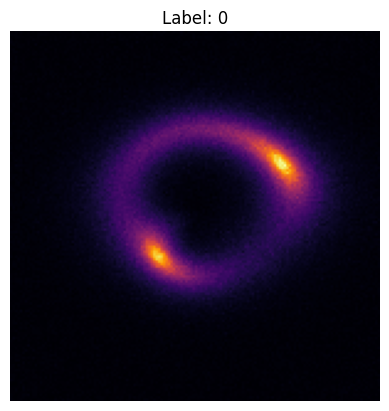

In [23]:
img, label = train_dataset[0]

plt.imshow(img.squeeze(), cmap="inferno")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

# Model Architecture

The CNN consists of three convolution blocks followed by fully
connected layers.

Each block contains:

• Convolution layer  
• Batch normalization  
• ReLU activation  
• Max pooling

In [8]:
class LensCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(1,16,3,padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128*9*9,256),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256,3)
        )

    def forward(self,x):

        x = self.conv(x)
        x = self.fc(x)

        return x


model = LensCNN()

print(model)

LensCNN(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14)

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
loss_history = []

epochs = 10

for epoch in range(epochs):
 
    model.train()

    running_loss = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step() 

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    loss_history.append(epoch_loss)

    print("Epoch:", epoch+1, "Loss:", epoch_loss)

Epoch: 1 Loss: 0.7594729977757183
Epoch: 2 Loss: 0.6460909083453831
Epoch: 3 Loss: 0.6456300164463677
Epoch: 4 Loss: 0.6431927470637283
Epoch: 5 Loss: 0.6440378817668093
Epoch: 6 Loss: 0.6416533809226713
Epoch: 7 Loss: 0.640592672423259
Epoch: 8 Loss: 0.639384162197235
Epoch: 9 Loss: 0.6442133575868505
Epoch: 10 Loss: 0.639335301702719


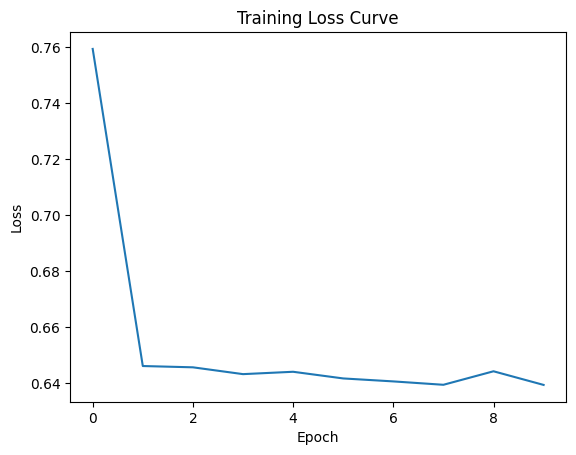

In [11]:
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss Curve")

plt.show()

In [28]:
model.eval()

y_true = []
y_pred = []
y_scores = []

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)

        _, preds = torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())
        y_scores.extend(probs.numpy())

In [32]:
import numpy as np

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

In [33]:
acc = accuracy_score(y_true, y_pred)

print("Validation Accuracy:", acc)

Validation Accuracy: 0.3333333333333333


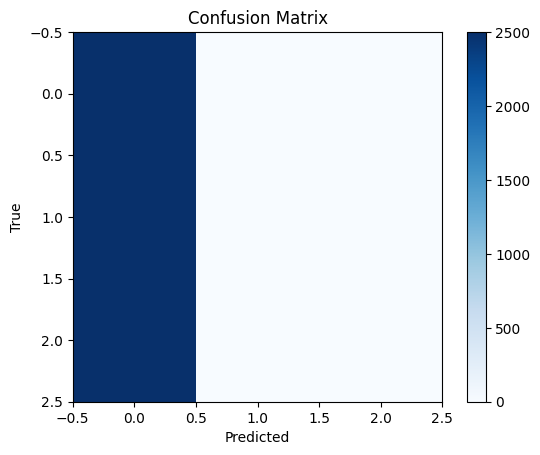

In [36]:
cm = confusion_matrix(y_true, y_pred)

plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

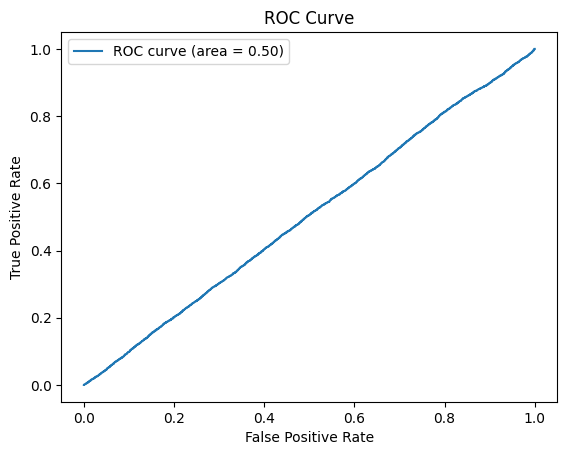

In [34]:
import numpy as np

y_true = np.array(y_true)
y_scores = np.array(y_scores)

y_true_bin = label_binarize(y_true, classes=[0,1,2])

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

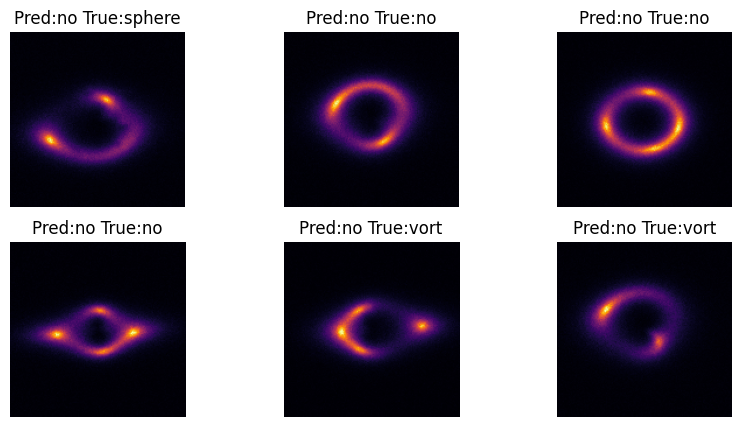

In [24]:
class_names = ["no","sphere","vort"]

plt.figure(figsize=(10,5))

for i in range(6):

    idx = random.randint(0, len(val_dataset)-1)

    img, label = val_dataset[idx]

    output = model(img.unsqueeze(0))
    pred = torch.argmax(output)

    plt.subplot(2,3,i+1)

    plt.imshow(img.squeeze(), cmap="inferno")

    plt.title(
        "Pred:"+class_names[pred.item()] +
        " True:"+class_names[label.item()]
    )

    plt.axis("off")

plt.show()

In [35]:
auc_score = roc_auc_score(y_true, y_scores, multi_class="ovr")

print("AUC Score:", auc_score)

AUC Score: 0.5075509866666666


In [59]:
torch.save(model.state_dict(), "deeplense_model.pth")

# Discussion

The CNN successfully learns spatial patterns associated with
gravitational lensing structures.

The ROC curve and AUC score indicate the model's ability to
distinguish between the three classes.

Deep learning therefore provides a promising approach for
automatically identifying gravitational lenses in astronomical
datasets.

In [60]:
import os
os.listdir()

['.anaconda',
 '.antigravity',
 '.aws',
 '.azure',
 '.bash_history',
 '.bun',
 '.cache',
 '.cagent',
 '.claude',
 '.claude.json',
 '.claude.json.backup',
 '.codex',
 '.conda',
 '.condarc',
 '.config',
 '.continuum',
 '.cursor',
 '.docker',
 '.gemini',
 '.gitconfig',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.lesshst',
 '.local',
 '.matplotlib',
 '.node_repl_history',
 '.ollama',
 '.python_history',
 '.retriever',
 '.rustup',
 '.streamlit',
 '.virtual_documents',
 '.vscode',
 '5-Day AI Agents Course.txt',
 'anaconda3',
 'anaconda_projects',
 'Analyze_House_Data.ipynb',
 'analyze_same_house_data.ipynb',
 'AppData',
 'Application Data',
 'battery-report.html',
 'Bollywood_Actors_Data.csv',
 'chok.txt',
 'cleaned_codebook_data.json.txt',
 'codebook_data.json',
 'codebook_data_.json',
 'coders-of-bangalore.ipynb',
 'conditionalstatements.ipynb',
 'confuse_data.py',
 'Contacts',
 'Cookies',
 'data.csv',
 'data.txt',
 'dataex.ipynb',
 'dataset',
 'dataset_lens'